# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

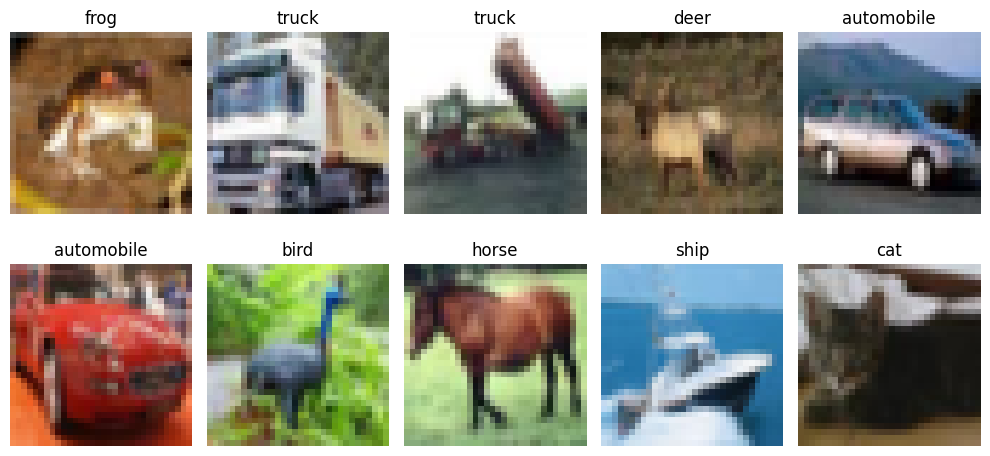

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.2721 - loss: 2.0001 - val_accuracy: 0.3378 - val_loss: 1.8609
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 35ms/step - accuracy: 0.3169 - loss: 1.8733 - val_accuracy: 0.3502 - val_loss: 1.7955
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3374 - loss: 1.8172 - val_accuracy: 0.3716 - val_loss: 1.7715
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3584 - loss: 1.7656 - val_accuracy: 0.4022 - val_loss: 1.6972
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3625 - loss: 1.7415 - val_accuracy: 0.3974 - val_loss: 1.7031
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.3707 - loss: 1.7254 - val_accuracy: 0.4030 - val_loss: 1.6787
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.3810 - loss: 1.7019 - val_accuracy: 0.4092 - val_loss: 1.6757
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.3866 - loss: 1.6863 - 

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4315 - loss: 1.6255
ANN Test Accuracy: 0.43149998784065247


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 99s 136ms/step - accuracy: 0.4567 - loss: 1.5144 - val_accuracy: 0.5100 - val_loss: 1.3808
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.5980 - loss: 1.1518 - val_accuracy: 0.5462 - val_loss: 1.3788
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 131ms/step - accuracy: 0.6587 - loss: 0.9830 - val_accuracy: 0.6112 - val_loss: 1.2122
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 136ms/step - accuracy: 0.7000 - loss: 0.8637 - val_accuracy: 0.6730 - val_loss: 0.9695
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.7322 - loss: 0.7635 - val_accuracy: 0.6952 - val_loss: 0.8710
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.7579 - loss: 0.6846 - val_accuracy: 0.7268 - val_loss: 0.8223
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 130ms/step - accuracy: 0.7845 - loss: 0.6170 - val_accuracy: 0.7338 - val_loss: 0.8035
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 129ms/step - accuracy: 0.8024 - loss

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6302 - loss: 1.3059
CNN Test Accuracy: 0.6302000284194946


## 📈 Compare Learning Curves

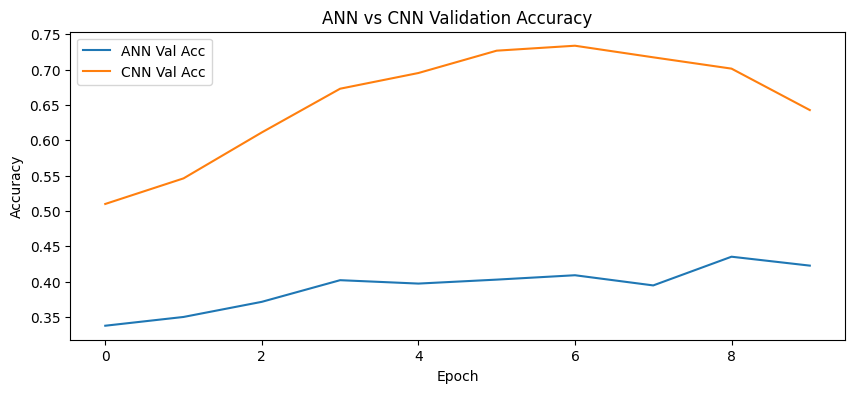

In [10]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [12]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4315
1,CNN,0.6302


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

In [13]:
deep_ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

deep_ann_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

deep_ann_history = deep_ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

deep_ann_test_loss, deep_ann_test_acc = deep_ann_model.evaluate(x_test_flat, y_test)
print("Original ANN Test Accuracy:", ann_test_acc)
print("Deeper ANN Test Accuracy:", deep_ann_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 76ms/step - accuracy: 0.2474 - loss: 2.0319 - val_accuracy: 0.3400 - val_loss: 1.8407
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 76ms/step - accuracy: 0.3116 - loss: 1.8790 - val_accuracy: 0.3592 - val_loss: 1.7854
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 77ms/step - accuracy: 0.3397 - loss: 1.8110 - val_accuracy: 0.3888 - val_loss: 1.7371
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.3491 - loss: 1.7848 - val_accuracy: 0.4050 - val_loss: 1.7249
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.3638 - loss: 1.7552 - val_accuracy: 0.3890 - val_loss: 1.7051
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 77ms/step - accuracy: 0.3714 - loss: 1.7376 - val_accuracy: 0.3966 - val_loss: 1.7023
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 77ms/step - accuracy: 0.3761 - loss: 1.7140 - val_accuracy: 0.4076 - val_loss: 1.6546
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 76ms/step - accuracy: 0.3836 - loss: 1.6993 - 

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 161s 224ms/step - accuracy: 0.4492 - loss: 1.5491 - val_accuracy: 0.5324 - val_loss: 1.3315
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 198s 218ms/step - accuracy: 0.5914 - loss: 1.1583 - val_accuracy: 0.6522 - val_loss: 0.9959
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 156s 221ms/step - accuracy: 0.6562 - loss: 0.9828 - val_accuracy: 0.6670 - val_loss: 0.9737
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 149s 212ms/step - accuracy: 0.7013 - loss: 0.8626 - val_accuracy: 0.7038 - val_loss: 0.8455
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 154s 219ms/step - accuracy: 0.7336 - loss: 0.7658 - val_accuracy: 0.7290 - val_loss: 0.7736
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 218ms/step - accuracy: 0.7581 - loss: 0.6899 - val_accuracy: 0.6866 - val_loss: 0.9295
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 203s 219ms/step - accuracy: 0.7820 - loss: 0.6194 - val_accuracy: 0.7486 - val_loss: 0.7702
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 204s 222ms/step - accuracy: 0.8004 -

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

aug_early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[aug_early_stop]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 102ms/step - accuracy: 0.3657 - loss: 1.7428 - val_accuracy: 0.4762 - val_loss: 1.4093
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 97ms/step - accuracy: 0.4647 - loss: 1.4935 - val_accuracy: 0.5144 - val_loss: 1.3403
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 99ms/step - accuracy: 0.5007 - loss: 1.4006 - val_accuracy: 0.5624 - val_loss: 1.2279
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.5267 - loss: 1.3359 - val_accuracy: 0.5964 - val_loss: 1.1289
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.5398 - loss: 1.2964 - val_accuracy: 0.6042 - val_loss: 1.1447
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 99ms/step - accuracy: 0.5535 - loss: 1.2627 - val_accuracy: 0.6070 - val_loss: 1.1116
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 101ms/step - accuracy: 0.5610 - loss: 1.2369 - val_accuracy: 0.6252 - val_loss: 1.0527
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 100ms/step - accuracy: 0.5722 - loss: 1.21

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**